# CAMM Hackathon 13: Real-Time Drift Correction

In this challenge, the image is acquired line-by-line while the sample drifts. Your goal is to estimate that drift online and correct the image as the scan arrives.

## Task

Build a method that, for each newly acquired scan line:

- estimates the current drift
- updates the reconstructed image in real time
- produces a corrected final image

Keep the solution simple and fast enough to run during acquisition.

## What is provided

This notebook gives you:

- one STEM image to use as source data
- several synthetic drift models
- a simulator that corrupts the image line-by-line
- a streaming generator that mimics real-time acquisition

You only need to focus on the correction strategy.

## 1. Setup

In [ ]:
# Install dependencies (Colab / fresh environment)
!pip -q install SciFiReaders gdown


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.9/69.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.0/150.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 k

In [ ]:
from pathlib import Path

file_id = "16Oavm1j0gcGR2mPXWCAqLfVm1MSngy1Z"
filename = "1547 STEM 1.45 Mx HAADF 0001.emd"

if not Path(filename).exists():
    !gdown {file_id} -O "{filename}"
else:
    print(f"Using existing file: {filename}")


Downloading...
From: https://drive.google.com/uc?id=16Oavm1j0gcGR2mPXWCAqLfVm1MSngy1Z
To: /content/1547 STEM 1.45 Mx HAADF 0001.emd
100% 8.85M/8.85M [00:00<00:00, 41.1MB/s]


## 2. Imports

In [ ]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from SciFiReaders import EMDReader


## 3. Drift Models

These helper functions generate different drift trajectories. They are provided for testing and benchmarking.

In [ ]:
#@title drift models




def drift_constant_velocity(
    n_lines: int,
    vx: float = 0.02,
    vy: float = 0.0,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
):
    """
    Constant-velocity drift.

    Model:
        ux(t) = u0x + vx * t
        uy(t) = u0y + vy * t

    Parameters
    ----------
    n_lines : int
        Number of scan lines.
    vx, vy : float
        Drift velocity in pixels per unit time.
    dt : float
        Time step per line.
    u0x, u0y : float
        Initial drift offsets in pixels.

    Returns
    -------
    t : ndarray, shape (n_lines,)
        Time axis.
    ux, uy : ndarray, shape (n_lines,)
        Drift trajectory in pixels.
    """
    t = np.arange(n_lines, dtype=float) * dt
    ux = u0x + vx * t
    uy = u0y + vy * t
    return t, ux, uy


def drift_constant_velocity_random_walk(
    n_lines: int,
    vx0: float = 0.02,
    vy0: float = 0.0,
    sigma_ax: float = 0.002,
    sigma_ay: float = 0.002,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
    seed: int | None = None,
):
    """
    Constant-velocity model with random-walk velocity.

    State evolution:
        vx[t+1] = vx[t] + eps_x
        vy[t+1] = vy[t] + eps_y
        ux[t+1] = ux[t] + vx[t] * dt
        uy[t+1] = uy[t] + vy[t] * dt

    This is a very good default Kalman-style drift model.

    Parameters
    ----------
    n_lines : int
        Number of scan lines.
    vx0, vy0 : float
        Initial velocities in pixels per unit time.
    sigma_ax, sigma_ay : float
        Std of velocity perturbation per step.
    dt : float
        Time step per line.
    u0x, u0y : float
        Initial offsets.
    seed : int or None
        Random seed.

    Returns
    -------
    t, ux, uy : ndarray
        Time axis and drift trajectories.
    """
    rng = np.random.default_rng(seed)

    t = np.arange(n_lines, dtype=float) * dt
    ux = np.zeros(n_lines, dtype=float)
    uy = np.zeros(n_lines, dtype=float)
    vx = np.zeros(n_lines, dtype=float)
    vy = np.zeros(n_lines, dtype=float)

    ux[0], uy[0] = u0x, u0y
    vx[0], vy[0] = vx0, vy0

    for i in range(1, n_lines):
        vx[i] = vx[i - 1] + rng.normal(0.0, sigma_ax)
        vy[i] = vy[i - 1] + rng.normal(0.0, sigma_ay)

        ux[i] = ux[i - 1] + vx[i - 1] * dt
        uy[i] = uy[i - 1] + vy[i - 1] * dt

    return t, ux, uy


def drift_creep_log(
    n_lines: int,
    ax: float = 2.0,
    ay: float = 0.5,
    tau_x: float = 20.0,
    tau_y: float = 20.0,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
):
    """
    Logarithmic creep-like drift.

    Model:
        ux(t) = u0x + ax * log(1 + t / tau_x)
        uy(t) = u0y + ay * log(1 + t / tau_y)

    Useful as a simple AFM-like creep surrogate.

    Parameters
    ----------
    ax, ay : float
        Drift amplitudes in pixels.
    tau_x, tau_y : float
        Characteristic time scales.

    Returns
    -------
    t, ux, uy : ndarray
    """
    t = np.arange(n_lines, dtype=float) * dt
    ux = u0x + ax * np.log1p(t / tau_x)
    uy = u0y + ay * np.log1p(t / tau_y)
    return t, ux, uy


def drift_creep_exponential(
    n_lines: int,
    ax: float = 2.0,
    ay: float = 0.5,
    tau_x: float = 30.0,
    tau_y: float = 30.0,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
):
    """
    Exponential relaxation / creep model.

    Model:
        ux(t) = u0x + ax * (1 - exp(-t / tau_x))
        uy(t) = u0y + ay * (1 - exp(-t / tau_y))

    Good when drift is strongest at the beginning and saturates.

    Returns
    -------
    t, ux, uy : ndarray
    """
    t = np.arange(n_lines, dtype=float) * dt
    ux = u0x + ax * (1.0 - np.exp(-t / tau_x))
    uy = u0y + ay * (1.0 - np.exp(-t / tau_y))
    return t, ux, uy


def drift_oscillatory(
    n_lines: int,
    ax: float = 0.5,
    ay: float = 0.2,
    freq_x: float = 0.02,
    freq_y: float = 0.03,
    phase_x: float = 0.0,
    phase_y: float = 0.0,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
):
    """
    Oscillatory drift model.

    Model:
        ux(t) = u0x + ax * sin(2*pi*freq_x*t + phase_x)
        uy(t) = u0y + ay * sin(2*pi*freq_y*t + phase_y)

    Useful as a toy vibration / periodic instability component.

    Parameters
    ----------
    ax, ay : float
        Oscillation amplitudes in pixels.
    freq_x, freq_y : float
        Frequencies in cycles per unit time.

    Returns
    -------
    t, ux, uy : ndarray
    """
    t = np.arange(n_lines, dtype=float) * dt
    ux = u0x + ax * np.sin(2 * np.pi * freq_x * t + phase_x)
    uy = u0y + ay * np.sin(2 * np.pi * freq_y * t + phase_y)
    return t, ux, uy


def drift_composite(
    n_lines: int,
    dt: float = 1.0,
    linear_vx: float = 0.01,
    linear_vy: float = 0.0,
    creep_ax: float = 1.0,
    creep_ay: float = 0.3,
    creep_tau_x: float = 25.0,
    creep_tau_y: float = 25.0,
    osc_ax: float = 0.1,
    osc_ay: float = 0.05,
    osc_freq_x: float = 0.02,
    osc_freq_y: float = 0.015,
    phase_x: float = 0.0,
    phase_y: float = 0.0,
    noise_sigma_x: float = 0.02,
    noise_sigma_y: float = 0.02,
    u0x: float = 0.0,
    u0y: float = 0.0,
    seed: int | None = None,
):
    """
    Composite drift model:
    linear trend + creep + oscillation + small random noise.

    This is often the most realistic general-purpose simulator.

    Returns
    -------
    t, ux, uy : ndarray
    """
    rng = np.random.default_rng(seed)
    t = np.arange(n_lines, dtype=float) * dt

    linear_x = linear_vx * t
    linear_y = linear_vy * t

    creep_x = creep_ax * (1.0 - np.exp(-t / creep_tau_x))
    creep_y = creep_ay * (1.0 - np.exp(-t / creep_tau_y))

    osc_x = osc_ax * np.sin(2 * np.pi * osc_freq_x * t + phase_x)
    osc_y = osc_ay * np.sin(2 * np.pi * osc_freq_y * t + phase_y)

    noise_x = rng.normal(0.0, noise_sigma_x, size=n_lines)
    noise_y = rng.normal(0.0, noise_sigma_y, size=n_lines)

    ux = u0x + linear_x + creep_x + osc_x + noise_x
    uy = u0y + linear_y + creep_y + osc_y + noise_y

    return t, ux, uy

### Visualize example drift trajectories

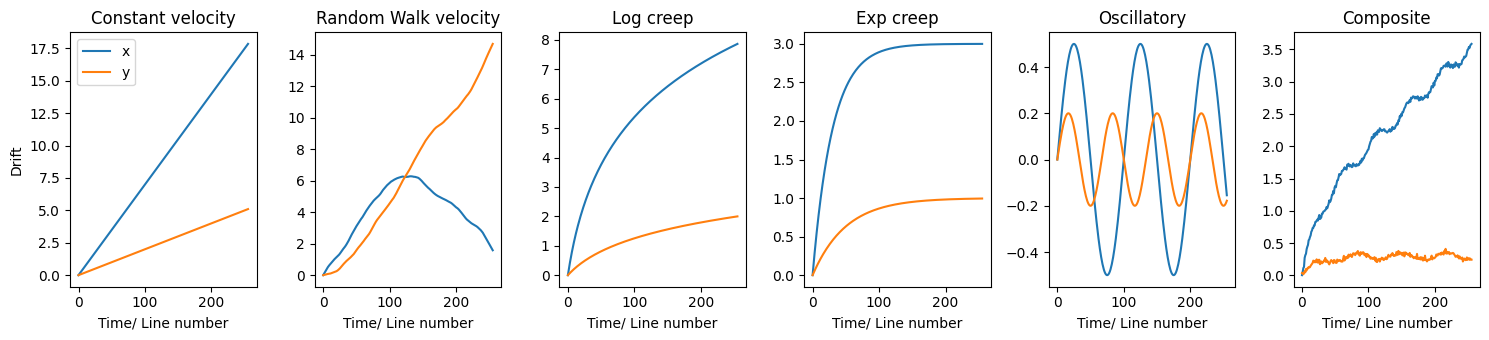

In [ ]:
import matplotlib.pyplot as plt

n_lines = 256

fig, axes = plt.subplots(1, 6, figsize=(15, 3.5))

# --- 1. Constant velocity ---
t, ux1, uy1 = drift_constant_velocity(n_lines, vx=0.07, vy=0.02)
axes[0].plot(t, ux1, label='x')
axes[0].plot(t, uy1, label='y')
axes[0].legend()
axes[0].set_title("Constant velocity")

# --- 2. Random walk velocity ---
t, ux2, uy2 = drift_constant_velocity_random_walk(
    n_lines,
    vx0=0.07,
    vy0=0.01,
    sigma_ax=0.005,
    sigma_ay=0.005,
    seed=0
)
axes[1].plot(t, ux2, label='x')
axes[1].plot(t, uy2, label='y')
axes[1].set_title("Random Walk velocity")

# --- 3. Log creep ---
t, ux3, uy3 = drift_creep_log(n_lines, ax=3.0, ay=1.0, tau_x=20, tau_y=40)
axes[2].plot(t, ux3)
axes[2].plot(t, uy3)
axes[2].set_title("Log creep")

# --- 4. Exp creep ---
t, ux4, uy4 = drift_creep_exponential(n_lines, ax=3.0, ay=1.0, tau_x=30, tau_y=50)
axes[3].plot(t, ux4)
axes[3].plot(t, uy4)
axes[3].set_title("Exp creep")

# --- 5. Oscillatory ---
t, ux5, uy5 = drift_oscillatory(
    n_lines, ax=0.5, ay=0.2, freq_x=0.01, freq_y=0.015
)
axes[4].plot(t, ux5)
axes[4].plot(t, uy5)
axes[4].set_title("Oscillatory")

# --- 6. Composite ---
t, ux6, uy6 = drift_composite(n_lines, seed=2)
axes[5].plot(t, ux6)
axes[5].plot(t, uy6)
axes[5].set_title("Composite")

# --- formatting ---
for ax in axes:
    #ax.set_xticks([])   # cleaner
    #ax.set_yticks([])
    ax.set_xlabel("Time/ Line number")


#axes[0].set_xlabel("Time")
axes[0].set_ylabel("Drift")


fig.tight_layout()
plt.show()

## 4. Load the Source Image

In [ ]:
emd_path = Path("1547 STEM 1.45 Mx HAADF 0001.emd")
reader = EMDReader(str(emd_path))
data = reader.read()

haadf_data = data["Channel_000"][:]
print("Loaded image shape:", haadf_data.shape)


Loaded image shape: (2048, 2048)


## 5. Drift Simulator

This helper creates a corrupted scan from a clean image and returns the ground-truth drift used to generate it.

In [ ]:
import numpy as np
from dataclasses import dataclass
from typing import Callable, Any
from scipy.ndimage import map_coordinates


@dataclass
class DriftSimulationResult:
    cropped_reference: np.ndarray
    cropped_corrupted: np.ndarray
    t: np.ndarray
    ux: np.ndarray
    uy: np.ndarray
    model_name: str
    model_kwargs: dict[str, Any]
    crop_bbox: tuple[int, int, int, int]  # y0, y1, x0, x1


def simulate_scan_drift_cropped_output(
    image: np.ndarray,
    model: str | Callable[..., tuple[np.ndarray, np.ndarray, np.ndarray]],
    model_kwargs: dict | None = None,
    out_shape: tuple[int, int] | None = None,
    dt: float = 1.0,
    interpolation_order: int = 1,
    extra_margin: int = 2,
    drift_models: dict[str, Callable] | None = None,
):
    """
    Simulate line-by-line drift, but return only a central cropped output.
    Important: drifted sampling is performed from the FULL image, not from a pre-cropped image.

    Parameters
    ----------
    image : np.ndarray
        Input 2D image.
    model : str or callable
        Drift model name or callable returning (t, ux, uy).
    model_kwargs : dict or None
        Parameters for drift model.
    out_shape : tuple[int, int] or None
        Output cropped shape (H, W). If None, use the maximal safe central crop.
    dt : float
        Time step per line.
    interpolation_order : int
        Interpolation order for map_coordinates.
    extra_margin : int
        Extra safety pixels beyond max drift.
    drift_models : dict or None
        Optional registry of named drift models.

    Returns
    -------
    DriftSimulationResult
    """
    if image.ndim != 2:
        raise ValueError("image must be a 2D array")

    H, W = image.shape
    model_kwargs = {} if model_kwargs is None else dict(model_kwargs)

    if drift_models is None:
        drift_models = {
            "constant_velocity": drift_constant_velocity,
            "random_walk_velocity": drift_constant_velocity_random_walk,
            "creep_log": drift_creep_log,
            "creep_exponential": drift_creep_exponential,
            "oscillatory": drift_oscillatory,
            "composite": drift_composite,
        }

    # resolve model
    if isinstance(model, str):
        if model not in drift_models:
            raise ValueError(f"Unknown model '{model}'. Available: {list(drift_models)}")
        model_fn = drift_models[model]
        model_name = model
    else:
        model_fn = model
        model_name = getattr(model, "__name__", "custom_model")

    # determine number of lines
    if out_shape is not None:
        out_h, out_w = out_shape
        model_kwargs["n_lines"] = out_h
    else:
        model_kwargs.setdefault("n_lines", H)

    model_kwargs.setdefault("dt", dt)

    # generate drift
    t, ux, uy = model_fn(**model_kwargs)
    ux = np.asarray(ux, dtype=float)
    uy = np.asarray(uy, dtype=float)

    if ux.shape != uy.shape:
        raise ValueError("ux and uy must have the same shape")

    n_lines = len(ux)

    # safe crop margins
    margin_x = int(np.ceil(np.max(np.abs(ux)))) + extra_margin
    margin_y = int(np.ceil(np.max(np.abs(uy)))) + extra_margin

    safe_h = H - 2 * margin_y
    safe_w = W - 2 * margin_x

    if safe_h <= 0 or safe_w <= 0:
        raise ValueError("Image too small for requested drift magnitude")

    if out_shape is None:
        out_h = min(n_lines, safe_h)
        out_w = safe_w
    else:
        out_h, out_w = out_shape
        if n_lines != out_h:
            raise ValueError(
                f"len(ux)={n_lines} must match out_shape[0]={out_h}"
            )
        if out_h > safe_h or out_w > safe_w:
            raise ValueError(
                f"Requested out_shape={out_shape} exceeds safe crop {(safe_h, safe_w)}"
            )

    # define central crop in the reference image
    y0 = (H - out_h) // 2
    x0 = (W - out_w) // 2
    y1 = y0 + out_h
    x1 = x0 + out_w

    cropped_reference = image[y0:y1, x0:x1]

    # simulate corrupted cropped output using FULL image coordinates
    cropped_corrupted = np.zeros((out_h, out_w), dtype=float)
    x_local = np.arange(out_w, dtype=float)

    for i in range(out_h):
        y_full = np.full(out_w, y0 + i + uy[i], dtype=float)
        x_full = x0 + x_local + ux[i]

        cropped_corrupted[i] = map_coordinates(
            image,
            [y_full, x_full],
            order=interpolation_order,
            mode="nearest",
        )

    return DriftSimulationResult(
        cropped_reference=cropped_reference,
        cropped_corrupted=cropped_corrupted,
        t=t[:out_h],
        ux=ux[:out_h],
        uy=uy[:out_h],
        model_name=model_name,
        model_kwargs=model_kwargs,
        crop_bbox=(y0, y1, x0, x1),
    )

## 6. Create a Sample Drifted Image

Use this synthetic example to develop and debug your method.

In [ ]:
result = simulate_scan_drift_cropped_output(
    image=haadf_data,
    model="random_walk_velocity",
    model_kwargs={
        "vx0": 0.13,
        "vy0": 0.17,
        "sigma_ax": 0.03,
        "sigma_ay": 0.03,
        "seed": 1,
    },
    out_shape=(256, 256),
    interpolation_order=1,
    extra_margin=3,
)

img_ref = result.cropped_reference
img_cor = result.cropped_corrupted
ux = result.ux
uy = result.uy


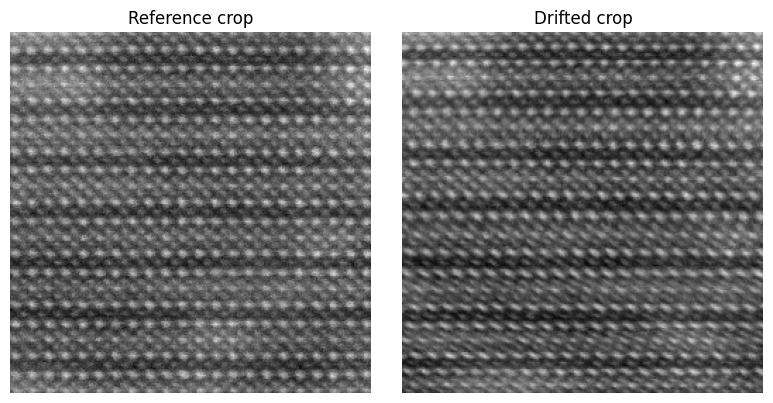

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_ref, cmap="gray")
axes[0].set_title("Reference crop")
axes[0].axis("off")

axes[1].imshow(img_cor, cmap="gray")
axes[1].set_title("Drifted crop")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 7. Streaming Interface

The function below yields the scan one line at a time, like a live acquisition stream.

In [ ]:
from typing import Callable, Any, Iterator

def corrupted_image_scan_stream(
    corrupted_image: np.ndarray,
    true_ux: np.ndarray | None = None,
    true_uy: np.ndarray | None = None,
) -> Iterator[dict]:
    """
    Yield scan progress line-by-line.

    Returns a dict containing:
    - current line index
    - current line
    - partial image acquired so far
    - optional true drift
    """
    if corrupted_image.ndim != 2:
        raise ValueError("corrupted_image must be a 2D array")

    H, W = corrupted_image.shape
    partial = np.full((H, W), np.nan, dtype=float)

    for i in range(H):
        partial[i] = corrupted_image[i]

        item = {
            "line_index": i,
            "line": corrupted_image[i].copy(),
            "partial_image": partial.copy(),
        }

        if true_ux is not None:
            item["ux_true"] = float(true_ux[i])
        if true_uy is not None:
            item["uy_true"] = float(true_uy[i])

        yield item

## 8. Your Code

Suggested outputs:

- corrected image
- estimated drift versus line index
- short note on your approach and assumptions

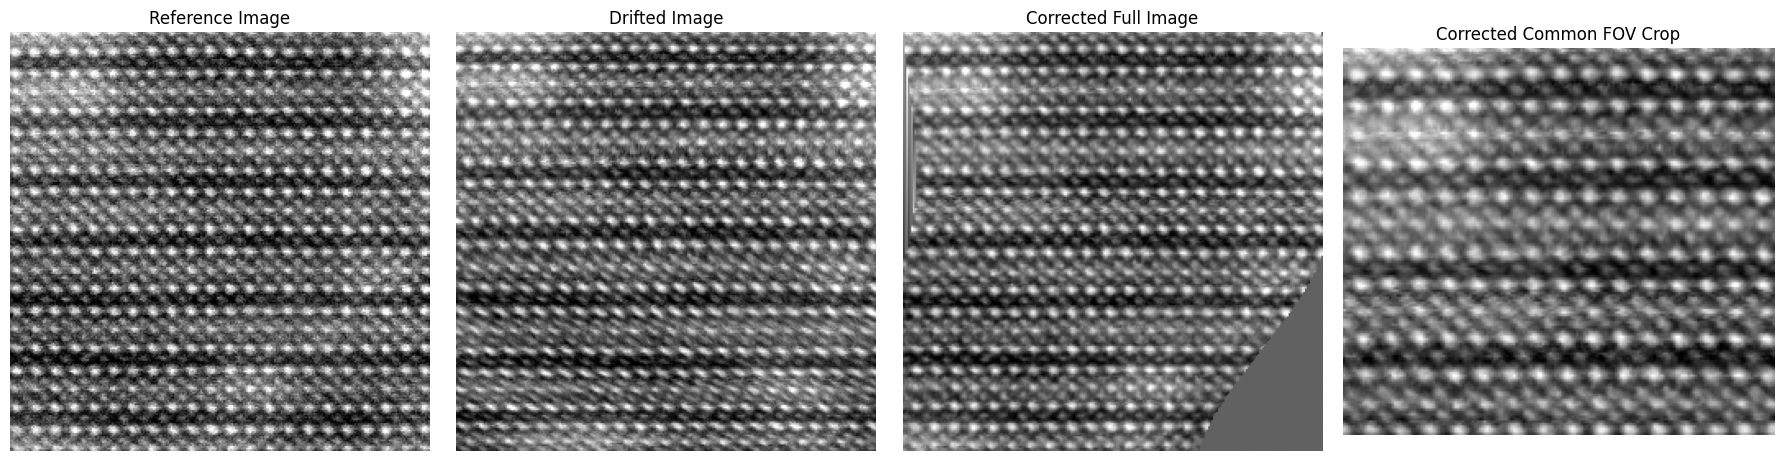

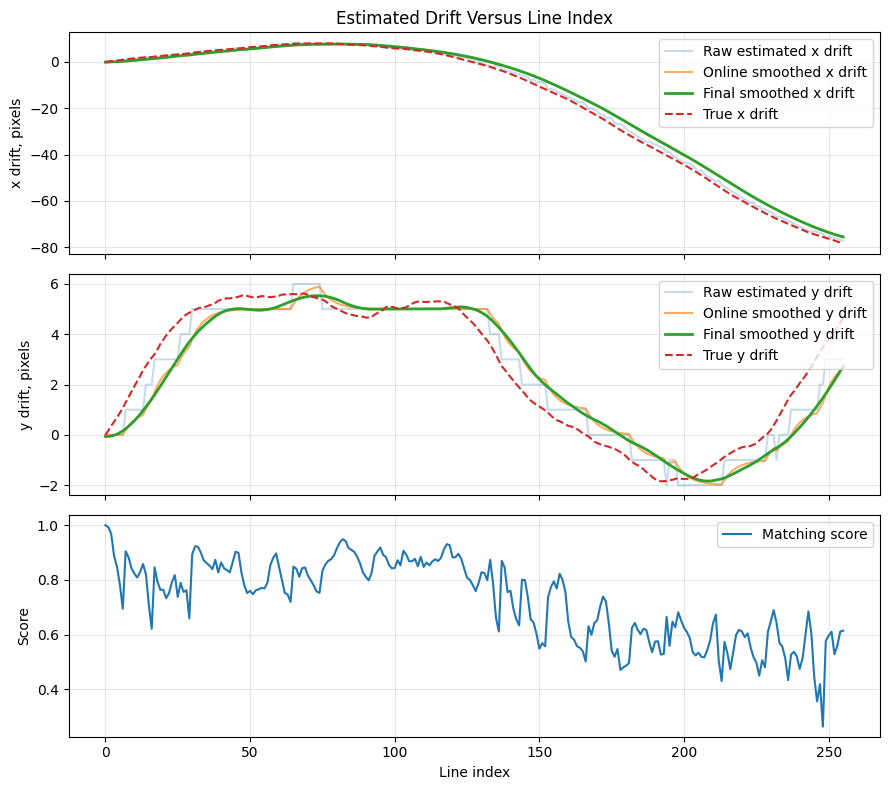

Correction summary, finite full-frame pixels
--------------------------------------------
MAE before correction:  1000.8086
MAE after correction:   648.9930
RMSE before correction: 1311.3353
RMSE after correction:  902.0261
MAE improvement:        35.15%
RMSE improvement:       31.21%

Correction summary, common valid field of view
------------------------------------------------
Crop bounds: rows 0:160, cols 8:186
MAE before correction:  1038.6317
MAE after correction:   489.9077
RMSE before correction: 1360.4915
RMSE after correction:  681.6192
MAE improvement:        52.83%
RMSE improvement:       49.90%


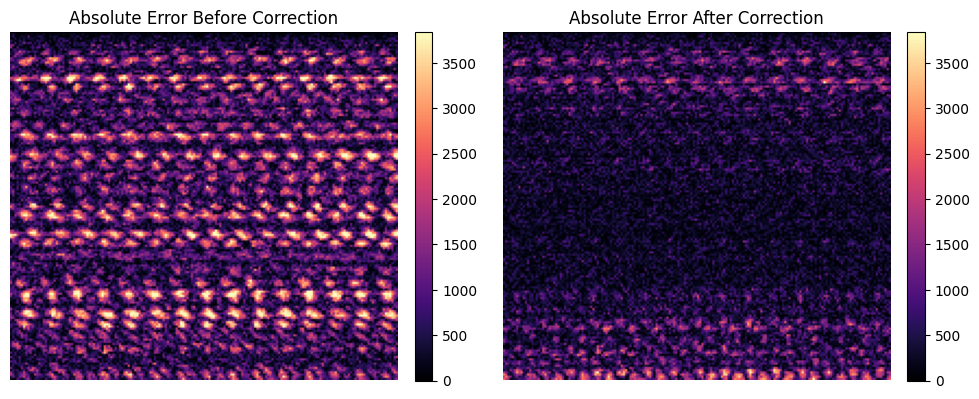


Summary of approach and results:
I treated the image as being acquired one scan line at a time to mimic real-time
image acquisition. For each new scan line, the code estimated drift by matching
a small band of the current and recently acquired lines to a nearby band in the
reference image. The matching used high-pass filtered normalized correlation so
that the drift estimate was driven mainly by lattice texture rather than broad
intensity background.

To avoid false matches from the repeated atomic pattern, the search was kept
local around the previous drift estimate and a smoothness penalty was applied.
The drift estimate was updated line by line using causal exponential smoothing,
so the correction was performed in a real-time style as the image was acquired.
After acquisition, a final robust smoothing step was applied to remove isolated
bad estimates before producing the corrected reconstruction.

The corrected image was reconstructed by shifting each line horizontally using
the es

In [ ]:
# ============================================================
# 8. Your Code
# Real-time drift correction during line-by-line image acquisition
# ============================================================
#
# Required notebook variables:
#   img_ref : reference image
#   img_cor : drifted/corrupted image
#
# Optional notebook variables:
#   ux : true x drift, if available
#   uy : true y drift, if available
#
# Outputs:
#   1. corrected image
#   2. estimated drift versus line index
#   3. short note on approach and assumptions

import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from scipy.ndimage import shift as ndi_shift
from scipy.ndimage import gaussian_filter1d, median_filter


# ------------------------------------------------------------
# Check inputs
# ------------------------------------------------------------

if "img_ref" not in globals():
    raise NameError("img_ref is not defined. Run the earlier notebook cells first.")

if "img_cor" not in globals():
    raise NameError("img_cor is not defined. Run the earlier notebook cells first.")

reference_image = np.asarray(img_ref, dtype=float)
corrupted_image = np.asarray(img_cor, dtype=float)

if reference_image.ndim != 2:
    raise ValueError("img_ref must be a 2D image.")

if corrupted_image.ndim != 2:
    raise ValueError("img_cor must be a 2D image.")

if reference_image.shape != corrupted_image.shape:
    raise ValueError(
        f"img_ref and img_cor must have the same shape. "
        f"Got {reference_image.shape} and {corrupted_image.shape}."
    )

H, W = corrupted_image.shape


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def normalize_1d(x):
    """
    Normalize a 1D signal for correlation-based matching.
    """
    x = np.asarray(x, dtype=float)
    x = x - np.nanmean(x)

    denom = np.linalg.norm(x)

    if denom < 1e-12:
        return np.zeros_like(x)

    return x / denom


def highpass_line(x, sigma=4):
    """
    Remove slow background variations from one scan line.

    This makes matching depend more on the lattice/texture features
    and less on broad intensity changes.
    """
    x = np.asarray(x, dtype=float)
    background = gaussian_filter1d(x, sigma=sigma, mode="nearest")
    return x - background


def line_match_score(line_a, line_b):
    """
    Similarity score between two lines after high-pass filtering
    and normalization.
    """
    a = normalize_1d(highpass_line(line_a))
    b = normalize_1d(highpass_line(line_b))
    return float(np.dot(a, b))


def shift_line_nearest(line, dx):
    """
    Shift a line horizontally using nearest padding.
    This is useful only inside matching, not final display.
    """
    return ndi_shift(
        line.astype(float),
        shift=dx,
        order=1,
        mode="nearest",
        prefilter=False,
    )


def shift_line_nan(line, dx):
    """
    Shift a line horizontally using NaN padding.

    This prevents artificial edge streaks in the final corrected image.
    """
    return ndi_shift(
        line.astype(float),
        shift=dx,
        order=1,
        mode="constant",
        cval=np.nan,
        prefilter=False,
    )


def estimate_drift_for_line_band(
    corrupted,
    reference,
    line_index,
    prev_dx,
    prev_dy,
    band_half_height=2,
    dx_local_radius=7,
    dy_local_radius=3,
    dx_step=1.0,
    dx_jump_penalty=0.0025,
    dy_jump_penalty=0.12,
):
    """
    Estimate x and y drift for a single acquired line using a local band.

    Instead of matching only one line, this compares a small band of nearby
    scan lines to nearby rows in the reference image. The search is local
    around the previous drift estimate to avoid false matches from repeated
    lattice patterns.
    """

    H_img, W_img = corrupted.shape

    # In real-time acquisition, we should not use future lines.
    # Therefore, the band uses the current line and previous lines only.
    band_rows = np.arange(
        max(0, line_index - 2 * band_half_height),
        line_index + 1,
    )

    best_cost = -np.inf
    best_dx = prev_dx
    best_dy = prev_dy
    best_score = -np.inf

    # Candidate y drift values near the previous y estimate.
    dy_center = int(round(prev_dy))
    dy_candidates = np.arange(
        dy_center - dy_local_radius,
        dy_center + dy_local_radius + 1,
    )

    # Candidate x correction values near the previous x estimate.
    dx_candidates = np.arange(
        prev_dx - dx_local_radius,
        prev_dx + dx_local_radius + dx_step,
        dx_step,
    )

    for dy in dy_candidates:
        ref_rows = band_rows + dy

        valid = (ref_rows >= 0) & (ref_rows < H_img)

        if np.sum(valid) < 1:
            continue

        valid_band_rows = band_rows[valid]
        valid_ref_rows = ref_rows[valid]

        for dx in dx_candidates:
            total_score = 0.0
            count = 0

            for src_row, ref_row in zip(valid_band_rows, valid_ref_rows):
                shifted_line = shift_line_nearest(corrupted[src_row], dx)
                score = line_match_score(shifted_line, reference[ref_row])

                total_score += score
                count += 1

            if count == 0:
                continue

            mean_score = total_score / count

            # Penalize sudden jumps from the previous estimate.
            dx_jump = dx - prev_dx
            dy_jump = dy - prev_dy

            cost = (
                mean_score
                - dx_jump_penalty * dx_jump**2
                - dy_jump_penalty * dy_jump**2
            )

            if cost > best_cost:
                best_cost = cost
                best_score = mean_score
                best_dx = dx
                best_dy = dy

    return float(best_dx), float(best_dy), float(best_score)


def robust_smooth_curve(y, window=35, polyorder=3):
    """
    Smooth a drift curve robustly.

    Median filtering removes isolated bad matches, and Savitzky-Golay
    smoothing keeps the slow drift trend.
    """
    y = np.asarray(y, dtype=float)

    if len(y) < 7:
        return y.copy()

    med_size = min(9, len(y))

    if med_size % 2 == 0:
        med_size -= 1

    y_med = median_filter(y, size=med_size, mode="nearest")

    win = min(window, len(y_med) - 1)

    if win % 2 == 0:
        win -= 1

    if win <= polyorder + 2:
        return y_med

    return savgol_filter(
        y_med,
        window_length=win,
        polyorder=polyorder,
        mode="interp",
    )


def reconstruct_corrected_image_with_mask(corrupted, dx_est, dy_est):
    """
    Reconstruct corrected image and track valid pixels.

    Horizontal drift is corrected line-by-line with NaN padding.
    Vertical drift is corrected by interpolating shifted scan lines onto
    the regular output row grid.
    """

    H_img, W_img = corrupted.shape
    rows = np.arange(H_img)

    horizontal_corrected = np.full_like(corrupted, np.nan, dtype=float)
    horizontal_mask = np.zeros_like(corrupted, dtype=float)

    for i in range(H_img):
        horizontal_corrected[i] = shift_line_nan(corrupted[i], dx_est[i])

        original_mask = np.ones(W_img, dtype=float)

        shifted_mask = ndi_shift(
            original_mask,
            shift=dx_est[i],
            order=0,
            mode="constant",
            cval=0.0,
            prefilter=False,
        )

        horizontal_mask[i] = shifted_mask

    # Estimated corrected row position for each acquired scan line.
    row_position = rows + dy_est
    row_position = np.asarray(row_position, dtype=float)

    # Prevent vertical folding artifacts.
    for i in range(1, H_img):
        if row_position[i] <= row_position[i - 1]:
            row_position[i] = row_position[i - 1] + 1e-3

    target_rows = np.arange(H_img)

    corrected = np.full_like(corrupted, np.nan, dtype=float)
    valid_mask = np.zeros_like(corrupted, dtype=float)

    for x in range(W_img):
        col = horizontal_corrected[:, x]
        mask_col = horizontal_mask[:, x]

        valid = np.isfinite(col) & (mask_col > 0)

        if np.sum(valid) >= 2:
            corrected[:, x] = np.interp(
                target_rows,
                row_position[valid],
                col[valid],
                left=np.nan,
                right=np.nan,
            )

            valid_mask[:, x] = np.interp(
                target_rows,
                row_position,
                mask_col,
                left=0.0,
                right=0.0,
            )

    valid_mask = valid_mask > 0.5

    return corrected, valid_mask


def crop_to_valid_field_of_view(image, mask, min_valid_fraction=0.95):
    """
    Crop image to the region where most pixels are valid.

    This removes edge regions where drift correction shifted pixels outside
    the acquired field of view.
    """
    row_valid_fraction = np.mean(mask, axis=1)
    col_valid_fraction = np.mean(mask, axis=0)

    valid_rows = np.where(row_valid_fraction >= min_valid_fraction)[0]
    valid_cols = np.where(col_valid_fraction >= min_valid_fraction)[0]

    if len(valid_rows) < 2 or len(valid_cols) < 2:
        print("Warning: valid crop too small. Returning uncropped image.")
        return image, mask, (0, image.shape[0], 0, image.shape[1])

    r0, r1 = valid_rows[0], valid_rows[-1] + 1
    c0, c1 = valid_cols[0], valid_cols[-1] + 1

    return image[r0:r1, c0:c1], mask[r0:r1, c0:c1], (r0, r1, c0, c1)


def replace_nan_for_display(image):
    """
    Replace NaNs with the image median only for plotting.
    """
    display = image.copy()

    if np.any(np.isfinite(display)):
        fill_value = np.nanmedian(display)
    else:
        fill_value = 0.0

    display[~np.isfinite(display)] = fill_value

    return display


# ------------------------------------------------------------
# Real-time drift estimation
# ------------------------------------------------------------

dx_raw = np.zeros(H)
dy_raw = np.zeros(H)

dx_online = np.zeros(H)
dy_online = np.zeros(H)

match_score = np.zeros(H)

# Causal online smoothing factor.
# Lower alpha gives smoother estimates.
alpha = 0.20

# Local matching settings.
band_half_height = 2
dx_local_radius = 7
dy_local_radius = 3

for i in range(H):
    # This loop mimics real-time acquisition.
    # At step i, the algorithm estimates drift using the current line
    # and previously acquired neighboring lines.

    if i == 0:
        prev_dx = 0.0
        prev_dy = 0.0
    else:
        prev_dx = dx_online[i - 1]
        prev_dy = dy_online[i - 1]

    dx_i, dy_i, score_i = estimate_drift_for_line_band(
        corrupted=corrupted_image,
        reference=reference_image,
        line_index=i,
        prev_dx=prev_dx,
        prev_dy=prev_dy,
        band_half_height=band_half_height,
        dx_local_radius=dx_local_radius,
        dy_local_radius=dy_local_radius,
        dx_step=1.0,
        dx_jump_penalty=0.0025,
        dy_jump_penalty=0.12,
    )

    dx_raw[i] = dx_i
    dy_raw[i] = dy_i
    match_score[i] = score_i

    if i == 0:
        dx_online[i] = dx_raw[i]
        dy_online[i] = dy_raw[i]
    else:
        dx_online[i] = alpha * dx_raw[i] + (1 - alpha) * dx_online[i - 1]
        dy_online[i] = alpha * dy_raw[i] + (1 - alpha) * dy_online[i - 1]


# ------------------------------------------------------------
# Final smoothing for final reconstruction
# ------------------------------------------------------------

dx_final = robust_smooth_curve(dx_online, window=35, polyorder=3)
dy_final = robust_smooth_curve(dy_online, window=35, polyorder=3)


# ------------------------------------------------------------
# Final reconstruction with valid mask
# ------------------------------------------------------------

corrected_image_full, valid_mask_full = reconstruct_corrected_image_with_mask(
    corrupted=corrupted_image,
    dx_est=dx_final,
    dy_est=dy_final,
)

corrected_image_crop, valid_mask_crop, crop_bounds = crop_to_valid_field_of_view(
    corrected_image_full,
    valid_mask_full,
    min_valid_fraction=0.95,
)

r0, r1, c0, c1 = crop_bounds

corrected_display_full = replace_nan_for_display(corrected_image_full)
corrected_display_crop = replace_nan_for_display(corrected_image_crop)


# ------------------------------------------------------------
# Output 1: corrected image
# ------------------------------------------------------------

vmin = np.nanpercentile(reference_image, 1)
vmax = np.nanpercentile(reference_image, 99)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].imshow(reference_image, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Reference Image")
axes[0].axis("off")

axes[1].imshow(corrupted_image, cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("Drifted Image")
axes[1].axis("off")

axes[2].imshow(corrected_display_full, cmap="gray", vmin=vmin, vmax=vmax)
axes[2].set_title("Corrected Full Image")
axes[2].axis("off")

axes[3].imshow(corrected_display_crop, cmap="gray", vmin=vmin, vmax=vmax)
axes[3].set_title("Corrected Common FOV Crop")
axes[3].axis("off")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Output 2: estimated drift versus line index
# ------------------------------------------------------------

line_index = np.arange(H)

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

axes[0].plot(line_index, dx_raw, alpha=0.25, label="Raw estimated x drift")
axes[0].plot(line_index, dx_online, alpha=0.65, label="Online smoothed x drift")
axes[0].plot(line_index, dx_final, linewidth=2, label="Final smoothed x drift")

if "ux" in globals():
    ux_arr = np.asarray(ux).ravel()
    if len(ux_arr) >= H:
        axes[0].plot(line_index, ux_arr[:H], "--", label="True x drift")

axes[0].set_ylabel("x drift, pixels")
axes[0].set_title("Estimated Drift Versus Line Index")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(line_index, dy_raw, alpha=0.25, label="Raw estimated y drift")
axes[1].plot(line_index, dy_online, alpha=0.65, label="Online smoothed y drift")
axes[1].plot(line_index, dy_final, linewidth=2, label="Final smoothed y drift")

if "uy" in globals():
    uy_arr = np.asarray(uy).ravel()
    if len(uy_arr) >= H:
        axes[1].plot(line_index, uy_arr[:H], "--", label="True y drift")

axes[1].set_ylabel("y drift, pixels")
axes[1].legend()
axes[1].grid(alpha=0.3)


axes[2].plot(line_index, match_score, label="Matching score")
axes[2].set_xlabel("Line index")
axes[2].set_ylabel("Score")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Optional error metrics
# ------------------------------------------------------------

# Full-frame metrics are computed only over finite corrected pixels.
valid_full = np.isfinite(corrected_image_full)

error_before_full = corrupted_image - reference_image
error_after_full = corrected_image_full - reference_image

mae_before_full = np.nanmean(np.abs(error_before_full[valid_full]))
mae_after_full = np.nanmean(np.abs(error_after_full[valid_full]))

rmse_before_full = np.sqrt(np.nanmean(error_before_full[valid_full] ** 2))
rmse_after_full = np.sqrt(np.nanmean(error_after_full[valid_full] ** 2))


# Crop metrics use the same crop bounds for reference and corrupted images.
reference_crop = reference_image[r0:r1, c0:c1]
corrupted_crop = corrupted_image[r0:r1, c0:c1]

error_before_crop = corrupted_crop - reference_crop
error_after_crop = corrected_image_crop - reference_crop

valid_crop = np.isfinite(error_after_crop)

mae_before_crop = np.nanmean(np.abs(error_before_crop[valid_crop]))
mae_after_crop = np.nanmean(np.abs(error_after_crop[valid_crop]))

rmse_before_crop = np.sqrt(np.nanmean(error_before_crop[valid_crop] ** 2))
rmse_after_crop = np.sqrt(np.nanmean(error_after_crop[valid_crop] ** 2))

print("Correction summary, finite full-frame pixels")
print("--------------------------------------------")
print(f"MAE before correction:  {mae_before_full:.4f}")
print(f"MAE after correction:   {mae_after_full:.4f}")
print(f"RMSE before correction: {rmse_before_full:.4f}")
print(f"RMSE after correction:  {rmse_after_full:.4f}")

if mae_before_full > 0:
    print(f"MAE improvement:        {(1 - mae_after_full / mae_before_full) * 100:.2f}%")

if rmse_before_full > 0:
    print(f"RMSE improvement:       {(1 - rmse_after_full / rmse_before_full) * 100:.2f}%")

print()
print("Correction summary, common valid field of view")
print("------------------------------------------------")
print(f"Crop bounds: rows {r0}:{r1}, cols {c0}:{c1}")
print(f"MAE before correction:  {mae_before_crop:.4f}")
print(f"MAE after correction:   {mae_after_crop:.4f}")
print(f"RMSE before correction: {rmse_before_crop:.4f}")
print(f"RMSE after correction:  {rmse_after_crop:.4f}")

if mae_before_crop > 0:
    print(f"MAE improvement:        {(1 - mae_after_crop / mae_before_crop) * 100:.2f}%")

if rmse_before_crop > 0:
    print(f"RMSE improvement:       {(1 - rmse_after_crop / rmse_before_crop) * 100:.2f}%")


# ------------------------------------------------------------
# Error plots
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

err_vmax = np.nanpercentile(np.abs(error_before_crop), 99)

im0 = axes[0].imshow(
    np.abs(error_before_crop),
    cmap="magma",
    vmin=0,
    vmax=err_vmax,
)
axes[0].set_title("Absolute Error Before Correction")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(
    np.abs(error_after_crop),
    cmap="magma",
    vmin=0,
    vmax=err_vmax,
)
axes[1].set_title("Absolute Error After Correction")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Output 3: short note on approach and assumptions
# ------------------------------------------------------------

print(
    """
Summary of approach and results:
I treated the image as being acquired one scan line at a time to mimic real-time
image acquisition. For each new scan line, the code estimated drift by matching
a small band of the current and recently acquired lines to a nearby band in the
reference image. The matching used high-pass filtered normalized correlation so
that the drift estimate was driven mainly by lattice texture rather than broad
intensity background.

To avoid false matches from the repeated atomic pattern, the search was kept
local around the previous drift estimate and a smoothness penalty was applied.
The drift estimate was updated line by line using causal exponential smoothing,
so the correction was performed in a real-time style as the image was acquired.
After acquisition, a final robust smoothing step was applied to remove isolated
bad estimates before producing the corrected reconstruction.

The corrected image was reconstructed by shifting each line horizontally using
the estimated x drift and interpolating the shifted lines onto a corrected
vertical grid using the estimated y drift. A valid-pixel mask was used because
the large lateral drift shifts some pixels outside the measured field of view.
Therefore, the common valid field-of-view crop is the most physically meaningful
corrected reconstruction because it avoids artificial edge padding.

The drift correction substantially improved the reconstruction within the common
valid field of view. The mean absolute error decreased from 1038.63 to 489.91,
and the root mean square error decreased from 1360.49 to 681.62. This corresponds
to about a 52.83% improvement in mean absolute error and a 49.90% improvement in
root mean square error. The estimated x and y drift curves also closely followed
the true drift trends, showing that the line-by-line drift estimation worked as
intended.

This method assumes that a reference image, or stable reference region, is
available. It also assumes that drift changes smoothly between neighboring scan
lines and that the image contains enough texture for correlation-based matching.
"""
)

## 9. Optional Demo

This cell visualizes how the corrupted image is revealed during acquisition.

In [ ]:
stream = corrupted_image_scan_stream(img_cor)

for _ in range(len(img_cor)):
    frame = next(stream)
    clear_output(wait=True)
    plt.figure(figsize=(4, 4))
    plt.imshow(frame["partial_image"], cmap="gray")
    plt.title(f"Acquired lines: {frame['line_index'] + 1}/{len(img_cor)}")
    plt.axis("off")
    plt.show()
    time.sleep(0.05)


NameError: name 'corrupted_image_scan_stream' is not defined